# Analysis Pipeline

## 0 Introduction

### Objective

This project constructs an annotation dataset to analyze linguistic strategies and their relationship with perceived emotional support in educational dialogue.

The workflow includes data preprocessing, annotation, and statistical analysis, with a focus on how different response types influence perceived support.

The repository is organized as a structured pipeline, from raw data preparation to final analysis.

## 0 Data Availability

The dataset used in this project is not publicly available due to restrictions imposed by the data provider.

Researchers interested in accessing the data should contact the original provider and obtain the necessary permissions:  
https://sig-edu.org/sharedtask/2023

Upon approval, I am happy to provide guidance and share the data processing scripts to help reproduce the analysis.

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1 Perceived Emotional Support Scoring

### 1.1 Annotator A

In [66]:
df = pd.read_csv("annot_data_full.csv", sep=";", engine="python")

In [67]:
annot_A = df.drop(columns=["Unnamed: 0"])
annot_A.rename(columns={"support_score": "support_A"}, inplace=True)

### 1.2 Annotator B

In [68]:
df_part1 = pd.read_csv("annot_data_part1.csv")
annot_B = df_part1.drop(columns=["Unnamed: 0"])
annot_B = annot_B.rename(columns={"support_score": "support_B"})

### 1.3 Annotator C

In [69]:
df_part2 = pd.read_csv("annot_data_part2.csv")
annot_C = df_part2.drop(columns=["Unnamed: 0"])
annot_C = annot_C.rename(columns={"support_score": "support_C"})

### 1.4 Data Merging

In [70]:
merged = annot_A.merge(
    annot_B[["id", "support_B"]],
    on="id",
    how="left"
).merge(
    annot_C[["id", "support_C"]],
    on="id",
    how="left"
)

In [128]:
merged.columns

Index(['id', 'context', 'teacher_response', 'support_A', 'support_B',
       'support_C'],
      dtype='object')

In [72]:
merged.isna().sum()

id                    0
context               0
teacher_response      0
support_A             0
support_B           252
support_C           251
dtype: int64

### 1.5 Data Cleaning and Validation

In [73]:
import numpy as np
merged = merged.replace(r"^\s*#\s*$", np.nan, regex=True)

cols = ["support_A", "support_B", "support_C"]
for col in cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

cols = ["support_A", "support_B", "support_C"]
for col in cols:
    merged[col] = merged[col].replace(0, 1)

In [74]:
merged[cols].head()

,support_A,support_B,support_C
0,1,1.0,NaN
1,3,3.0,NaN
2,3,1.0,NaN
3,2,1.0,NaN
4,5,3.0,NaN


In [75]:
merged.isna().sum()

id                    0
context               0
teacher_response      0
support_A             0
support_B           252
support_C           253
dtype: int64

### 1.6 Inter Annotator Agreement

In [76]:
ab = merged.drop(columns=["support_C"])
ac= merged.drop(columns=["support_B"])
ab["diff_A_B"] = (ab["support_A"] - ab["support_B"]).abs()
ac["diff_A_C"] = (ac["support_A"] - ac["support_C"]).abs()

In [77]:
count_diff_ab = ab["diff_A_B"].value_counts().sort_index()
percentage_diff_ab = ab["diff_A_B"].value_counts(normalize=True).sort_index()
result_diff_ab = pd.DataFrame(
   { "Count": count_diff_ab,
    "Percentage(%)": percentage_diff_ab * 100}
)
print(result_diff_ab.round(2))

          Count  Percentage(%)
diff_A_B                      
0.0          66          26.29
1.0         104          41.43
2.0          68          27.09
3.0          13           5.18


In [78]:
count_diff_ac = ac["diff_A_C"].value_counts().sort_index()
percentage_diff_ac = ac["diff_A_C"].value_counts(normalize=True).sort_index()
result_diff_ac = pd.DataFrame(
   { "Count": count_diff_ac,
    "Percentage(%)": percentage_diff_ac * 100}
)
print(result_diff_ac.round(2))

          Count  Percentage(%)
diff_A_C                      
0.0          57           22.8
1.0          99           39.6
2.0          81           32.4
3.0          12            4.8
4.0           1            0.4


In [79]:
df_plot = pd.DataFrame({
    "diff": percentage_diff_ab.index,
    "AB": percentage_diff_ab.values *100,
    "AC": percentage_diff_ac.reindex(percentage_diff_ab.index, fill_value=0).values * 100
})
df_plot = df_plot.melt(id_vars="diff", var_name="Pair", value_name="Percentage")

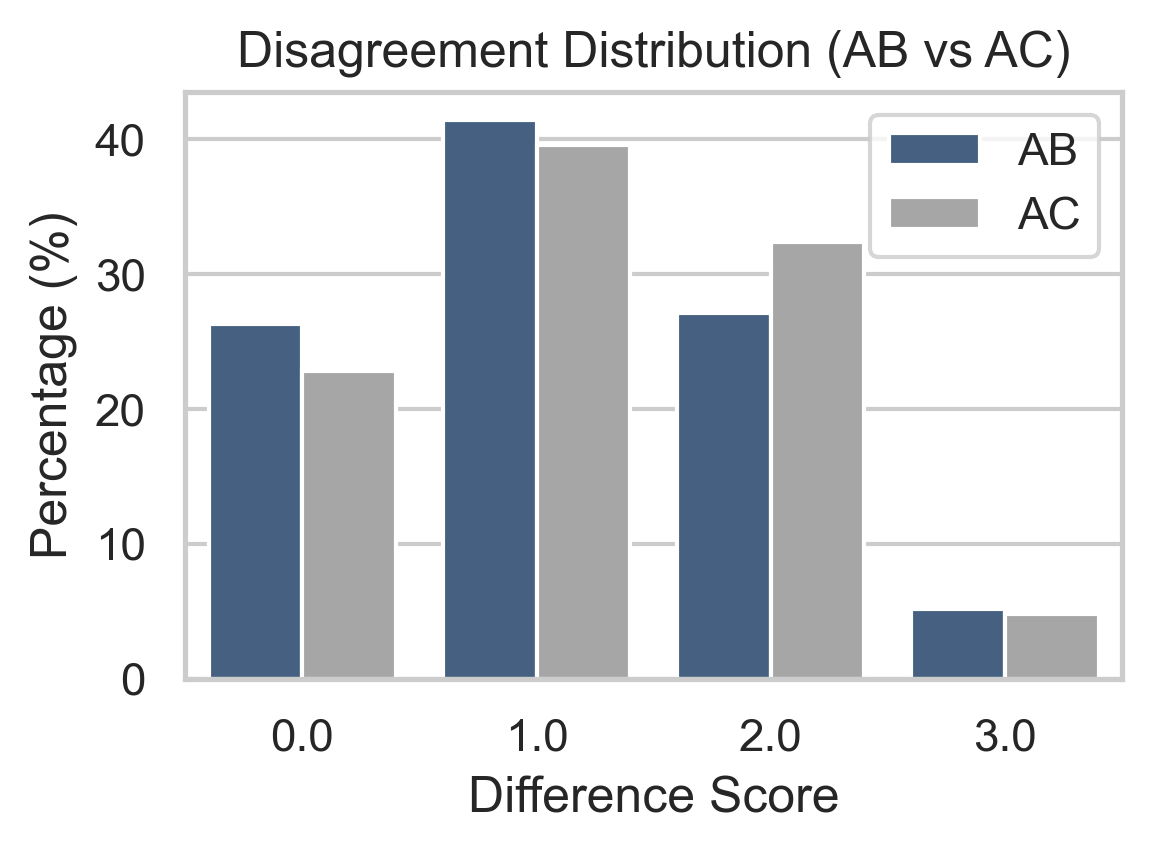

In [80]:
sns.set(style="whitegrid")

plt.figure(figsize=(4,3), dpi=300)

palette = {
    "AB": "#3B5F8A",
    "AC": "#A6A6A6"
}

sns.barplot(
    data=df_plot,
    x="diff",
    y="Percentage",
    hue="Pair",
    palette=palette
)

plt.title("Disagreement Distribution (AB vs AC)")
plt.xlabel("Difference Score")
plt.ylabel("Percentage (%)")

plt.legend(title="")
plt.tight_layout()

plt.show()

`Summary`

The distribution of score differences indicates a generally moderate level of agreement between annotators. Most ratings differ by 1 point (≈40%), followed by exact agreement (0 difference, ≈20–25%). Larger discrepancies (≥2 points) are less frequent, and differences of 3 or more are rare.

This pattern suggests that annotators broadly share similar judgments of perceived support, while still allowing for some variation due to the subjective nature of the task.

In [81]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

In [129]:
ab_extreme = ab[ab["diff_A_B"] >= 3]
ab_extreme.columns

Index(['id', 'context', 'teacher_response', 'support_A', 'support_B',
       'diff_A_B'],
      dtype='object')

In [130]:
ac_extreme = ac[ac["diff_A_C"] >= 3]
ac_extreme.columns

Index(['id', 'context', 'teacher_response', 'support_A', 'support_C',
       'diff_A_C'],
      dtype='object')

### 1.7 Score Aggregation (Mean)

In [131]:
score_agg = merged.copy()
score_agg["support_avg"] = score_agg[["support_A", "support_B", "support_C"]].mean(axis=1)
score_agg.columns

Index(['id', 'context', 'teacher_response', 'support_A', 'support_B',
       'support_C', 'support_avg'],
      dtype='object')

## 2 Teacher Response Type Annotation

In [85]:
df = pd.read_csv("teacher_type_of_response_annotation.csv", sep=";", engine="python")
df = df.drop(columns=["Unnamed: 0"])

### 2.1 Coverage of Response Type Annotation

In [132]:
type_response = df[[
    "id",
    "teacher_response",
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]].copy()

type_response["TR_total"] = type_response[
    ["TR_Empathy", "TR_Encouragement", "TR_Explanation", "TR_Directive"]
].sum(axis=1)

type_response["type_status"] = type_response["TR_total"].apply(
    lambda x: "No labeled" if x == 0 else "labeled at least one"
)

type_response.columns


Index(['id', 'teacher_response', 'TR_Empathy', 'TR_Encouragement',
       'TR_Explanation', 'TR_Directive', 'TR_total', 'type_status'],
      dtype='object')

In [87]:
# Calculate the number of responses with and without assigned response types
type_status_table = (
    type_response["type_status"]
    .value_counts()
    .rename_axis("Response Type Status")
    .reset_index(name="Count")
)

type_status_table["Percentage (%)"] = (
    type_status_table["Count"] / len(type_response) * 100
).round(2)

type_status_table

,Response Type Status,Count,Percentage (%)
0,labeled at least one,315,62.62
1,No labeled,188,37.38


In [88]:
# type of response: frequency
TR_count = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]].sum()

# type of response: percentage
TR_percentage = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive",
]].mean() * 100 

# number of different types per response
TR_per_response = type_response["TR_total"].value_counts().sort_index()

### 2.2 Distribution of Response Types

In [89]:
# Calculate the count and percentage of each response type
TR_cols = [
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]

summary_table = pd.DataFrame({
    "Count": TR_count,
    "Percentage (%)": TR_percentage.round(2)
})

# Include responses not assigned to any predefined type
no_labeled_count = (type_response["TR_total"] == 0).sum()
no_labeled_percentage = round(no_labeled_count / len(type_response) * 100, 2)

no_labeled_row = pd.DataFrame({
    "Count": [no_labeled_count],
    "Percentage (%)": [no_labeled_percentage]
}, index=["No labeled"])

summary_table_full = pd.concat([summary_table, no_labeled_row])

summary_table_full

,Count,Percentage (%)
TR_Empathy,38,7.55
TR_Encouragement,63,12.52
TR_Explanation,129,25.65
TR_Directive,116,23.06
No labeled,188,37.38


### 2.3 Distribution of Multiple Response Types

In [90]:
# multiple Types of Response 
multi_TR = (
    type_response[type_response["TR_total"] > 0]["TR_total"]
    .value_counts()
    .sort_index()
    .rename_axis("Type")
    .reset_index(name="Count")
)

multi_TR["Percentage (%)"] = (
    multi_TR["Count"] / len(type_response["TR_total"]) * 100
).round(2)

multi_TR = multi_TR.set_index("Type")
multi_TR

,Count,Percentage (%)
Type,,
1,285,56.66
2,29,5.77
3,1,0.20


## 3 Relationship Between Response Types and Perceived Support

In [135]:
type_response = type_response.merge(
    score_agg[["id", "support_avg"]],
    on="id",
    how="left"
)
type_response.columns

Index(['id', 'teacher_response', 'TR_Empathy', 'TR_Encouragement',
       'TR_Explanation', 'TR_Directive', 'TR_total', 'type_status',
       'support_avg_x', 'support_avg_y', 'support_avg'],
      dtype='object')

### 3.1 Descriptive Results

#### 3.1.1  Effects of Individual Response Types (Mean)
        (Empathy, Encouragement, Explanation, Directive)

In [92]:
# Empathy

TR_Em_score = (
    type_response
    .groupby("TR_Empathy", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Em_score["TR_Empathy"] = TR_Em_score["TR_Empathy"].map({
    0: "Not Used",
    1: "Used"
})

TR_Em_score.round(2)

,TR_Empathy,Average_Support_Score
0,Not Used,3.12
1,Used,3.64


In [93]:
# Encouragement

TR_Ec_score = (
    type_response
    .groupby("TR_Encouragement", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Ec_score["TR_Encouragement"] = TR_Ec_score["TR_Encouragement"].map({
    0: "Not Used",
    1: "Used"
})

TR_Ec_score.round(2)

,TR_Encouragement,Average_Support_Score
0,Not Used,3.08
1,Used,3.73


In [94]:
# Explanation

TR_Ex_score = (
    type_response
    .groupby("TR_Explanation", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Ex_score["TR_Explanation"] = TR_Ex_score["TR_Explanation"].map({
    0: "Not Used",
    1: "Used"
})

TR_Ex_score.round(2)

,TR_Explanation,Average_Support_Score
0,Not Used,3.13
1,Used,3.26


In [95]:
# Directive

TR_Dr_score = (
    type_response
    .groupby("TR_Directive", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Dr_score["TR_Directive"] = TR_Dr_score["TR_Directive"].map({
    0: "Not Used",
    1: "Used"
})

TR_Dr_score.round(2)

,TR_Directive,Average_Support_Score
0,Not Used,3.27
1,Used,2.80


In [96]:
summary_table = pd.DataFrame({
    "Response Type": ["Empathy", "Encouragement", "Explanation", "Directive"],
    "Used": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Used", "Average_Support_Score"].values[0],
    ],
    "Not Used": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Not Used", "Average_Support_Score"].values[0],
    ]
}).round(2)

summary_table.set_index("Response Type")

,Used,Not Used
Response Type,,
Empathy,3.64,3.12
Encouragement,3.73,3.08
Explanation,3.26,3.13
Directive,2.80,3.27


#### 3.1.2 Effects of Response Type Combinations (Mean)
    (No labeled types, Overall average, Multiple types, Single type)

In [97]:
# No labeled types
no_label_counts = type_response[type_response["TR_total"] == 0]["support_avg"].count()
no_label_score = type_response[type_response["TR_total"] == 0]["support_avg"].mean().round(2)
print ("The amount of responses aren't be annotated: ", no_label_counts)
print("The score of responses aren't be annotated: ", no_label_score)

The amount of responses aren't be annotated:  188
The score of responses aren't be annotated:  3.13


In [98]:
# Overall Average Support Score
total_counts = type_response["id"].count()
overall_score = type_response["support_avg"].mean().round(2)
print ("The total of responses: ", total_counts)
print("The score of overall average: ",overall_score)

The total of responses:  503
The score of overall average:  3.16


In [99]:
# Multiple types
multi_counts = type_response[type_response["TR_total"] > 1]["support_avg"].count()
multi_score = type_response[type_response["TR_total"] > 1]["support_avg"].mean().round(2)
print ("The responses annotated by multiple types are: ", multi_counts)
print("The score of multiple annotated responses: ",multi_score)

The responses annotated by multiple types are:  30
The score of multiple annotated responses:  3.73


In [100]:
# Combinations of Multiple types
multi = type_response[type_response["TR_total"] > 1].copy()

multi["combination"] = multi[
    ["TR_Empathy", "TR_Encouragement", "TR_Explanation", "TR_Directive"]
].apply(lambda x: tuple(x.index[x == 1]), axis=1)

combo_counts = multi["combination"].value_counts().reset_index()
combo_counts.columns = ["Combination", "Count"]

combo_counts["Combination"] = combo_counts["Combination"].apply(
    lambda x: ", ".join([i.replace("TR_", "") for i in x])
)

combo_counts["Percentage"] = (
    combo_counts["Count"] / combo_counts["Count"].sum() * 100
).round(1)

combo_counts

combo_counts.set_index("Combination")

,Count,Percentage
Combination,,
"Encouragement, Directive",11,36.7
"Encouragement, Explanation",9,30.0
"Empathy, Explanation",4,13.3
"Empathy, Encouragement",2,6.7
"Explanation, Directive",2,6.7
"Empathy, Explanation, Directive",1,3.3
"Empathy, Directive",1,3.3


In [101]:
# Single value type
single_value = type_response[type_response["TR_total"] == 1]["support_avg"].mean().round(2)
single_value

np.float64(3.12)

#### 3.1.3 Summary Comparison of Conditions

##### 3.1.3.1 Average Support Scores Across Conditions  

In [102]:
# Comparison of Average Score Base on the Response Type and Condition

comparison_table = pd.DataFrame({
    "Response Type": [
        "Empathy", "Empathy",
        "Encouragement", "Encouragement",
        "Explanation", "Explanation",
        "Directive", "Directive",
        "No Labeled",
        "Single Type",
        "Multiple Types",
        "Overall"
    ],
    "Condition": [
        "Used", "Not Used",
        "Used", "Not Used",
        "Used", "Not Used",
        "Used", "Not Used",
        "",
        "",
        "",
        ""
    ],
    "Average Support Score": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Used", "Average_Support_Score"].values[0],
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Not Used", "Average_Support_Score"].values[0],

        no_label_score,
        single_value,
        multi_score,
        overall_score
    ]
}).round(2)

comparison_table.set_index("Response Type")

,Condition,Average Support Score
Response Type,,
Empathy,Used,3.64
Empathy,Not Used,3.12
Encouragement,Used,3.73
Encouragement,Not Used,3.08
Explanation,Used,3.26
Explanation,Not Used,3.13
Directive,Used,2.80
Directive,Not Used,3.27
No Labeled,,3.13


In [103]:
# Preparation for the Visualization
plot_df = comparison_table[
    comparison_table["Response Type"].isin(["Empathy", "Encouragement", "Explanation", "Directive"])
]

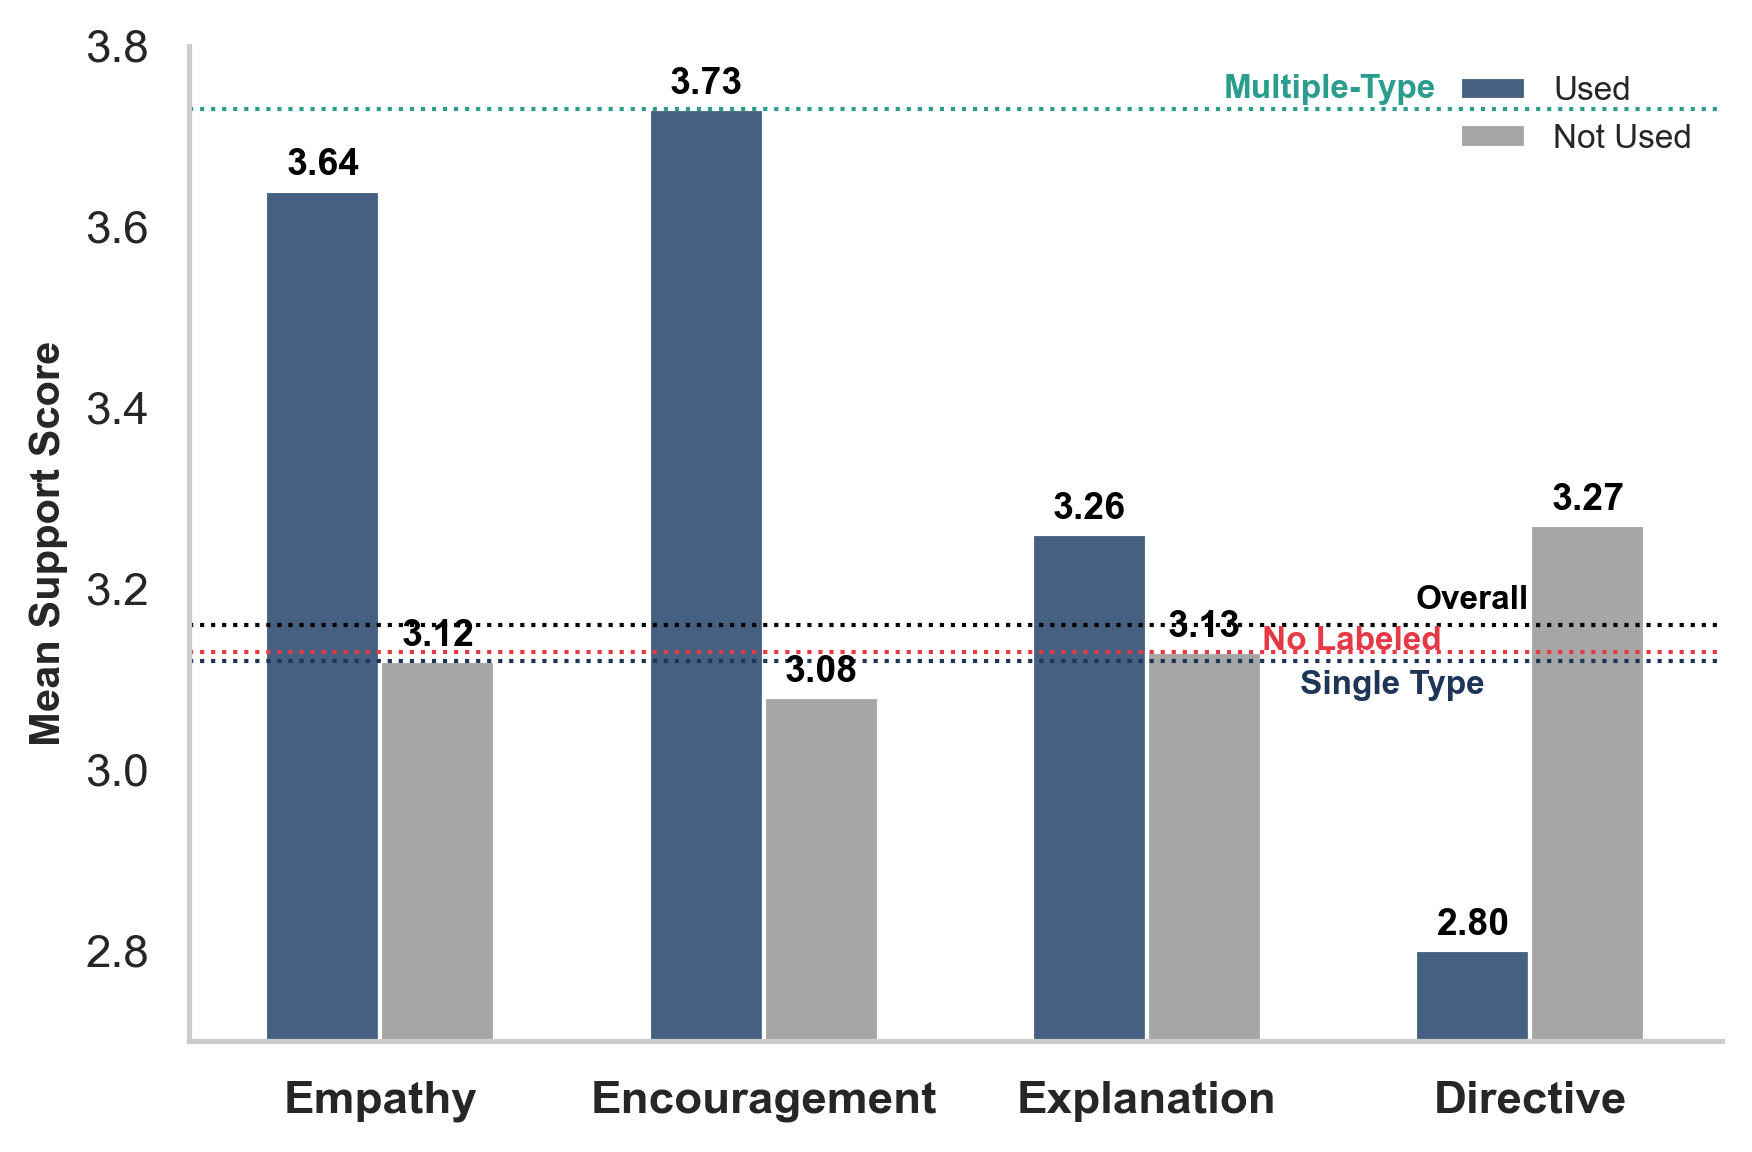

In [104]:
# Visualize the effect of different response types on perceived support scores(AVG)
plt.figure(figsize=(6,4), dpi=300)

palette = {
    "Used": "#3B5F8A",
    "Not Used": "#A6A6A6"
}

ax = sns.barplot(
    data=plot_df,
    x="Response Type",
    y="Average Support Score",
    hue="Condition",
    palette=palette,
    width=0.6
)

plt.ylim(2.7, 3.8)

# Reference lines
plt.axhline(no_label_score, linestyle=":", color="#E63946", linewidth=1)
plt.axhline(single_value, linestyle=":", color="#1D3557", linewidth=1)
plt.axhline(multi_score, linestyle=":", color="#2A9D8F", linewidth=1)
plt.axhline(overall_score, linestyle=":", color="#000000", linewidth=1)

# Annotate bar values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=9,
        color="black",
        xytext=(0, 2),
        textcoords='offset points',
        weight="bold"
    )

# line_text
plt.text(2.3, no_label_score - 0.005, "No Labeled", color="#E63946", fontsize=8, va="bottom", fontweight="bold")
plt.text(2.4, single_value - 0.01, "Single Type", color="#1D3557", fontsize=8, va="top", fontweight="bold")
plt.text(2.2, multi_score + 0.005, "Multiple-Type", color="#2A9D8F", fontsize=8, va="bottom", fontweight="bold")
plt.text(2.7, overall_score + 0.01, "Overall", color="#000000", fontsize=8, va="bottom", fontweight="bold")

# label
#plt.title("Effect of Response Types on Perceived Support (Mean)", fontsize=11)
plt.ylabel("Mean Support Score", fontsize=10, weight="bold")
plt.xlabel("")
plt.setp(ax.get_xticklabels(), fontweight='bold')

sns.despine()

# legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False, fontsize=8, loc="upper right")
plt.grid(axis='y', visible=False)
plt.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig("figure1.pdf", bbox_inches='tight')
plt.show()

`Summary`

Mean support scores vary clearly across response types and conditions. <b>Encouragement</b> and <b>Empathy</b> show the strongest positive association with perceived support when used, both substantially higher than when not used. <b>Explanation</b> exhibits only a modest increase, suggesting a limited effect on its own.

In contrast, <b>Directive responses</b> are associated with lower support scores when used alone. However, their effectiveness improves when combined with other response types, particularly affective ones, indicating that directive elements are not inherently unsupportive but interaction-dependent <i>(See in 3.1.2)</i>.

At the structural level, responses with <b>multiple types</b> achieve the highest average score, while <b>single-type</b> and <b>non-labeled</b> responses remain close to the overall baseline. Overall, these results suggest that affective strategies, especially when combined with other types, are more strongly associated with higher perceived support.

##### 3.1.3.2 High-Support Patterns Across Conditions

In [105]:
cols = []

# Total number of high-support responses (support_avg >= 4)
total_high = type_response[type_response["support_avg"] >= 4].shape[0]

# Function to compute statistics for a given condition
def compute_condition(name, condition):
    subset = type_response[condition]
    
    total = subset.shape[0]
    high = subset[subset["support_avg"] >= 4].shape[0]
    
    # Percentage of high-support responses within this condition
    ratio_within = round(high / total * 100, 2) if total > 0 else 0
    
    # Percentage relative to all high-support responses (global proportion)
    ratio_global = round(high / total_high * 100, 2) if total_high > 0 else 0
    
    cols.append({
        "Condition": name,
        "Total Count": total,
        "High Support Count": high,
        "High Support (%)": ratio_within,
        "High Support (Global %)": ratio_global
    })


# Compute statistics for each response type
compute_condition("Empathy", type_response["TR_Empathy"] == 1)
compute_condition("Encouragement", type_response["TR_Encouragement"] == 1)
compute_condition("Explanation", type_response["TR_Explanation"] == 1)
compute_condition("Directive", type_response["TR_Directive"] == 1)
compute_condition("No Label", type_response["TR_total"] == 0)
compute_condition("Multiple Types", type_response["TR_total"] > 1)


# Convert results to DataFrame
result_df = pd.DataFrame(cols)

# Display results
result_df.set_index("Condition")

,Total Count,High Support Count,High Support (%),High Support (Global %)
Condition,,,,
Empathy,38,20,52.63,12.66
Encouragement,63,33,52.38,20.89
Explanation,129,42,32.56,26.58
Directive,116,26,22.41,16.46
No Label,188,55,29.26,34.81
Multiple Types,30,17,56.67,10.76


**Note:** High Support (%) measures the likelihood that a response type leads to high perceived support (within-condition proportion), while High Support (Global %) reflects the distribution of high-support responses across conditions (overall contribution).


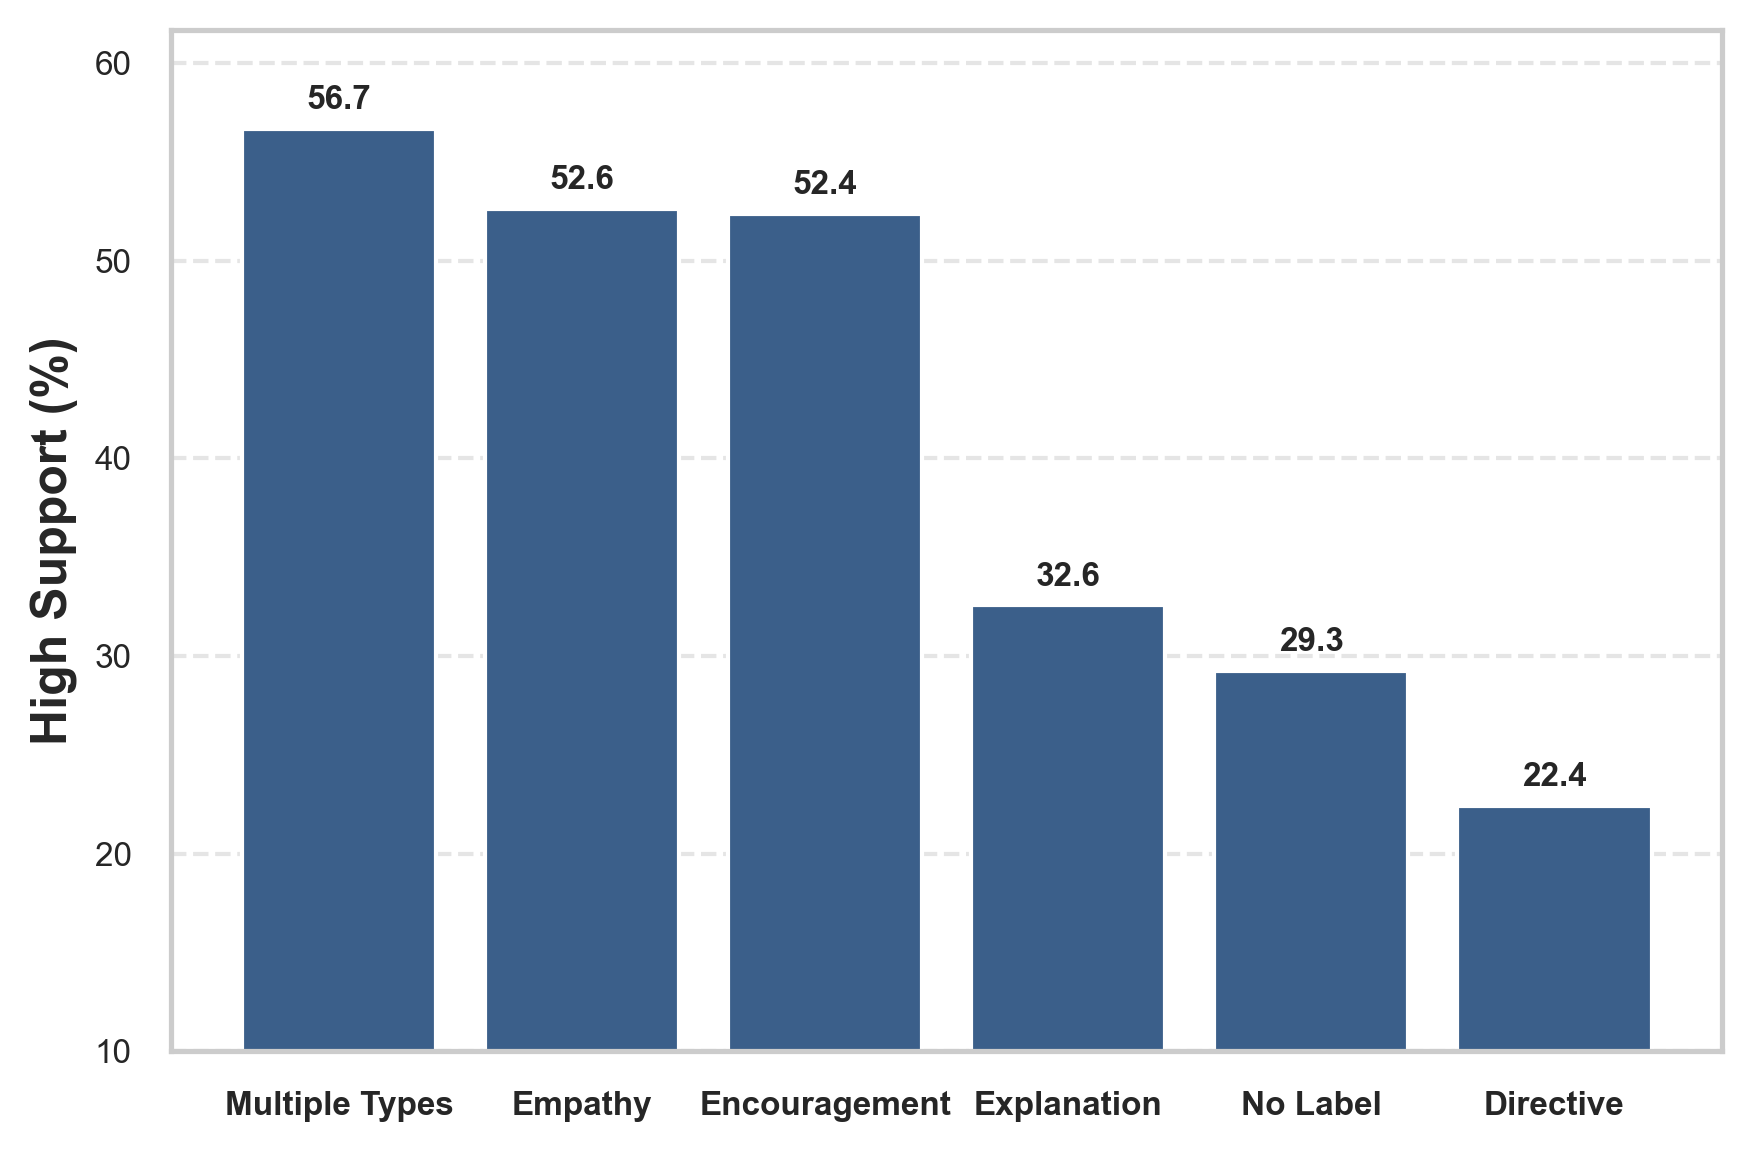

In [106]:
# High Support (%)（effectiveness）

# Sort in descending order for clarity
df1 = result_df.sort_values("High Support (%)", ascending=False)

plt.figure(figsize=(6,4), dpi=300)

plt.bar(
    df1["Condition"],
    df1["High Support (%)"],
    color="#3B5F8A"
)

# Add value labels
for i, v in enumerate(df1["High Support (%)"]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8,fontweight="bold")

plt.ylabel("High Support (%)", weight="bold")
# plt.title("High Support Rate by Response Type")

plt.xticks(rotation=0, fontsize=8, fontweight="bold")
plt.ylim(10, max(df1["High Support (%)"]) + 5)
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig("figure2.pdf", bbox_inches='tight')
plt.show()

`Summary`

This figure shows the proportion of high-support responses within each response type. Multiple Types yield the highest rate, followed by Empathy and Encouragement, while Explanation shows a moderate effect and Directive the lowest. This pattern indicates that affective and combined strategies are more effective in eliciting perceived emotional support than purely instructional or directive responses.

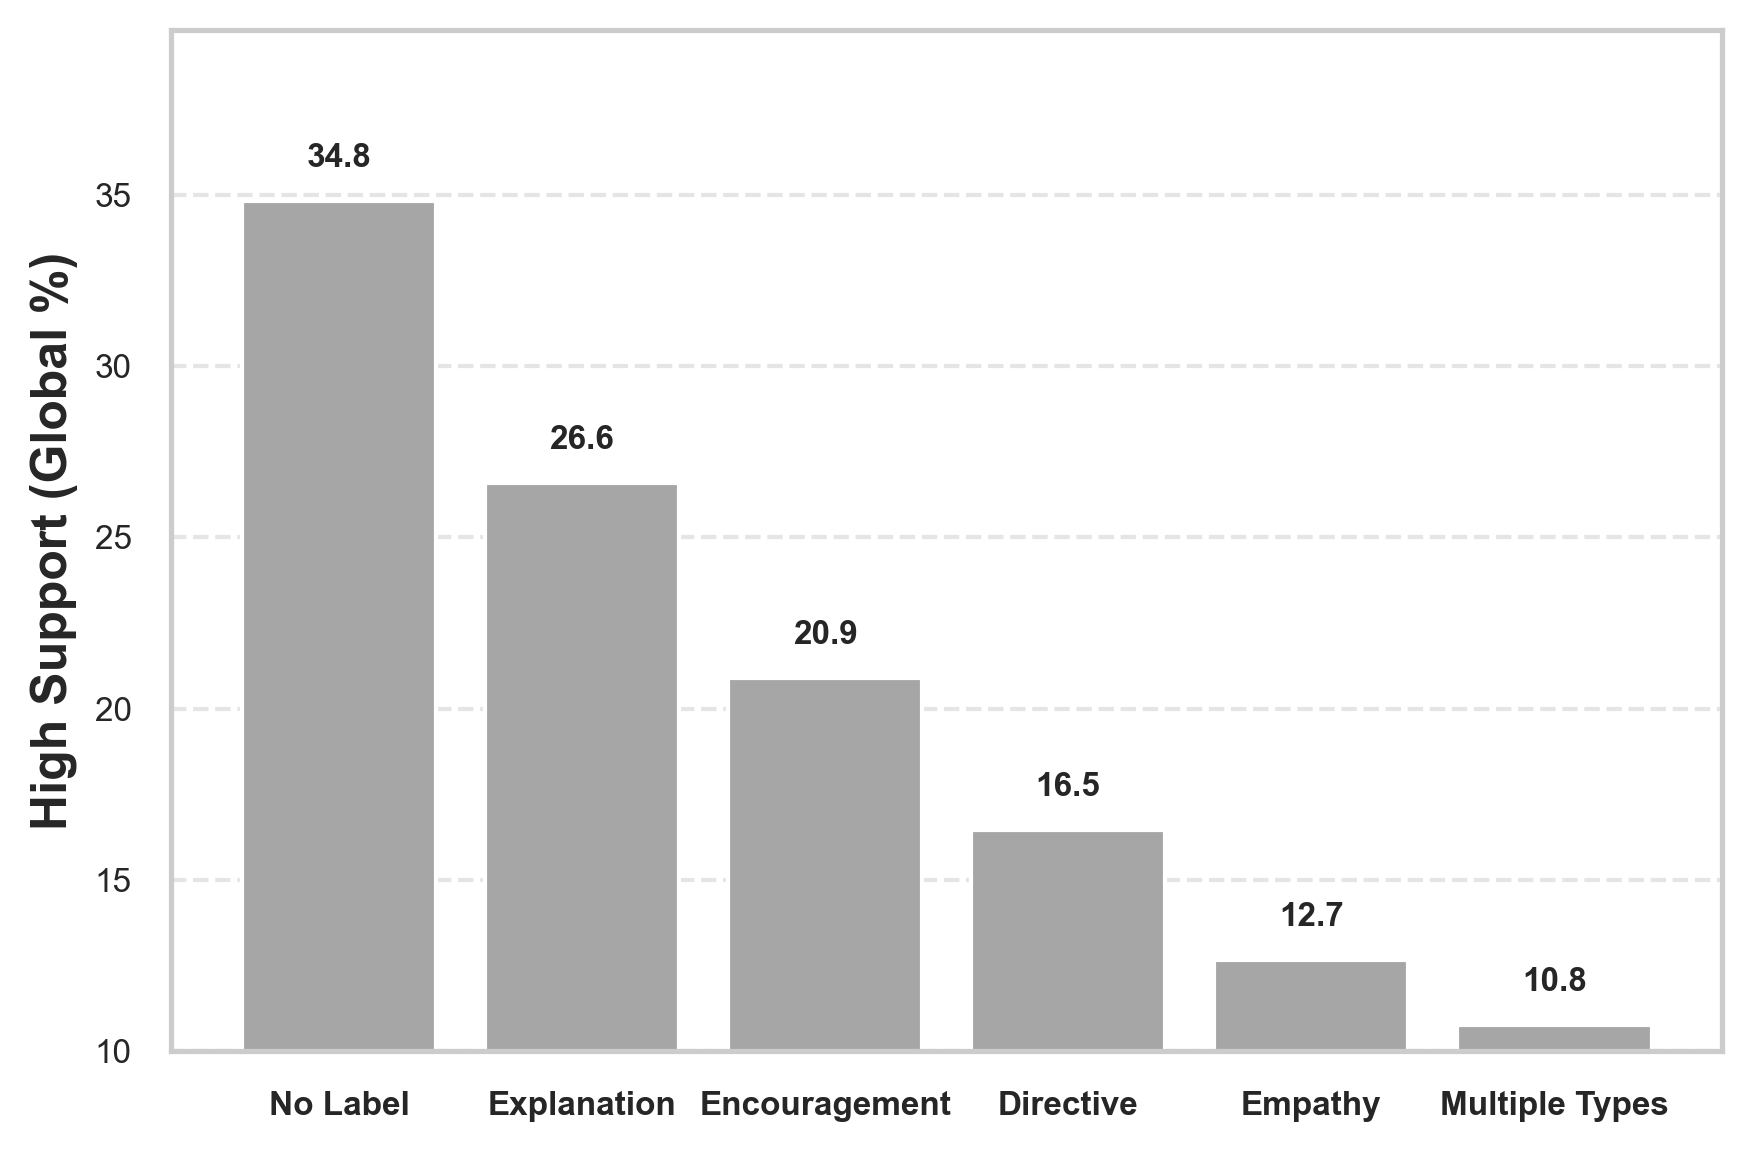

In [107]:
# High Support (Global %)（distribution）
# Sort in descending order 
df2 = result_df.sort_values("High Support (Global %)", ascending=False)

plt.figure(figsize=(6,4), dpi=300)

plt.bar(
    df2["Condition"],
    df2["High Support (Global %)"],
    color="#A6A6A6"
)

# Add value labels
for i, v in enumerate(df2["High Support (Global %)"]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

plt.ylabel("High Support (Global %)", weight="bold")
#plt.title("Contribution to High Support Responses")

plt.xticks(rotation=0, fontsize=8, fontweight="bold")
plt.ylim(10, max(df2["High Support (Global %)"]) + 5)
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)
plt.savefig("figure3.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

`Summary`

This figure shows the distribution of high-support responses across different response types.

Although Multiple Types have the highest effectiveness, their contribution is relatively low, suggesting they are not frequently used. In contrast, No Labeled responses contribute the largest share of high-support cases, likely due to their higher frequency.

The presence of high-support responses in the No Labeled category also suggests that some supportive strategies may not be captured by the current annotation scheme.

/var/folders/c8/vcr8t_yn0wq2rqnv1b7cqrvr0000gn/T/ipykernel_72085/1977498780.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df1["Condition"], rotation=0, fontsize=6, fontweight="bold")
/var/folders/c8/vcr8t_yn0wq2rqnv1b7cqrvr0000gn/T/ipykernel_72085/1977498780.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df2["Condition"], rotation=0, fontsize=7, fontweight="bold")


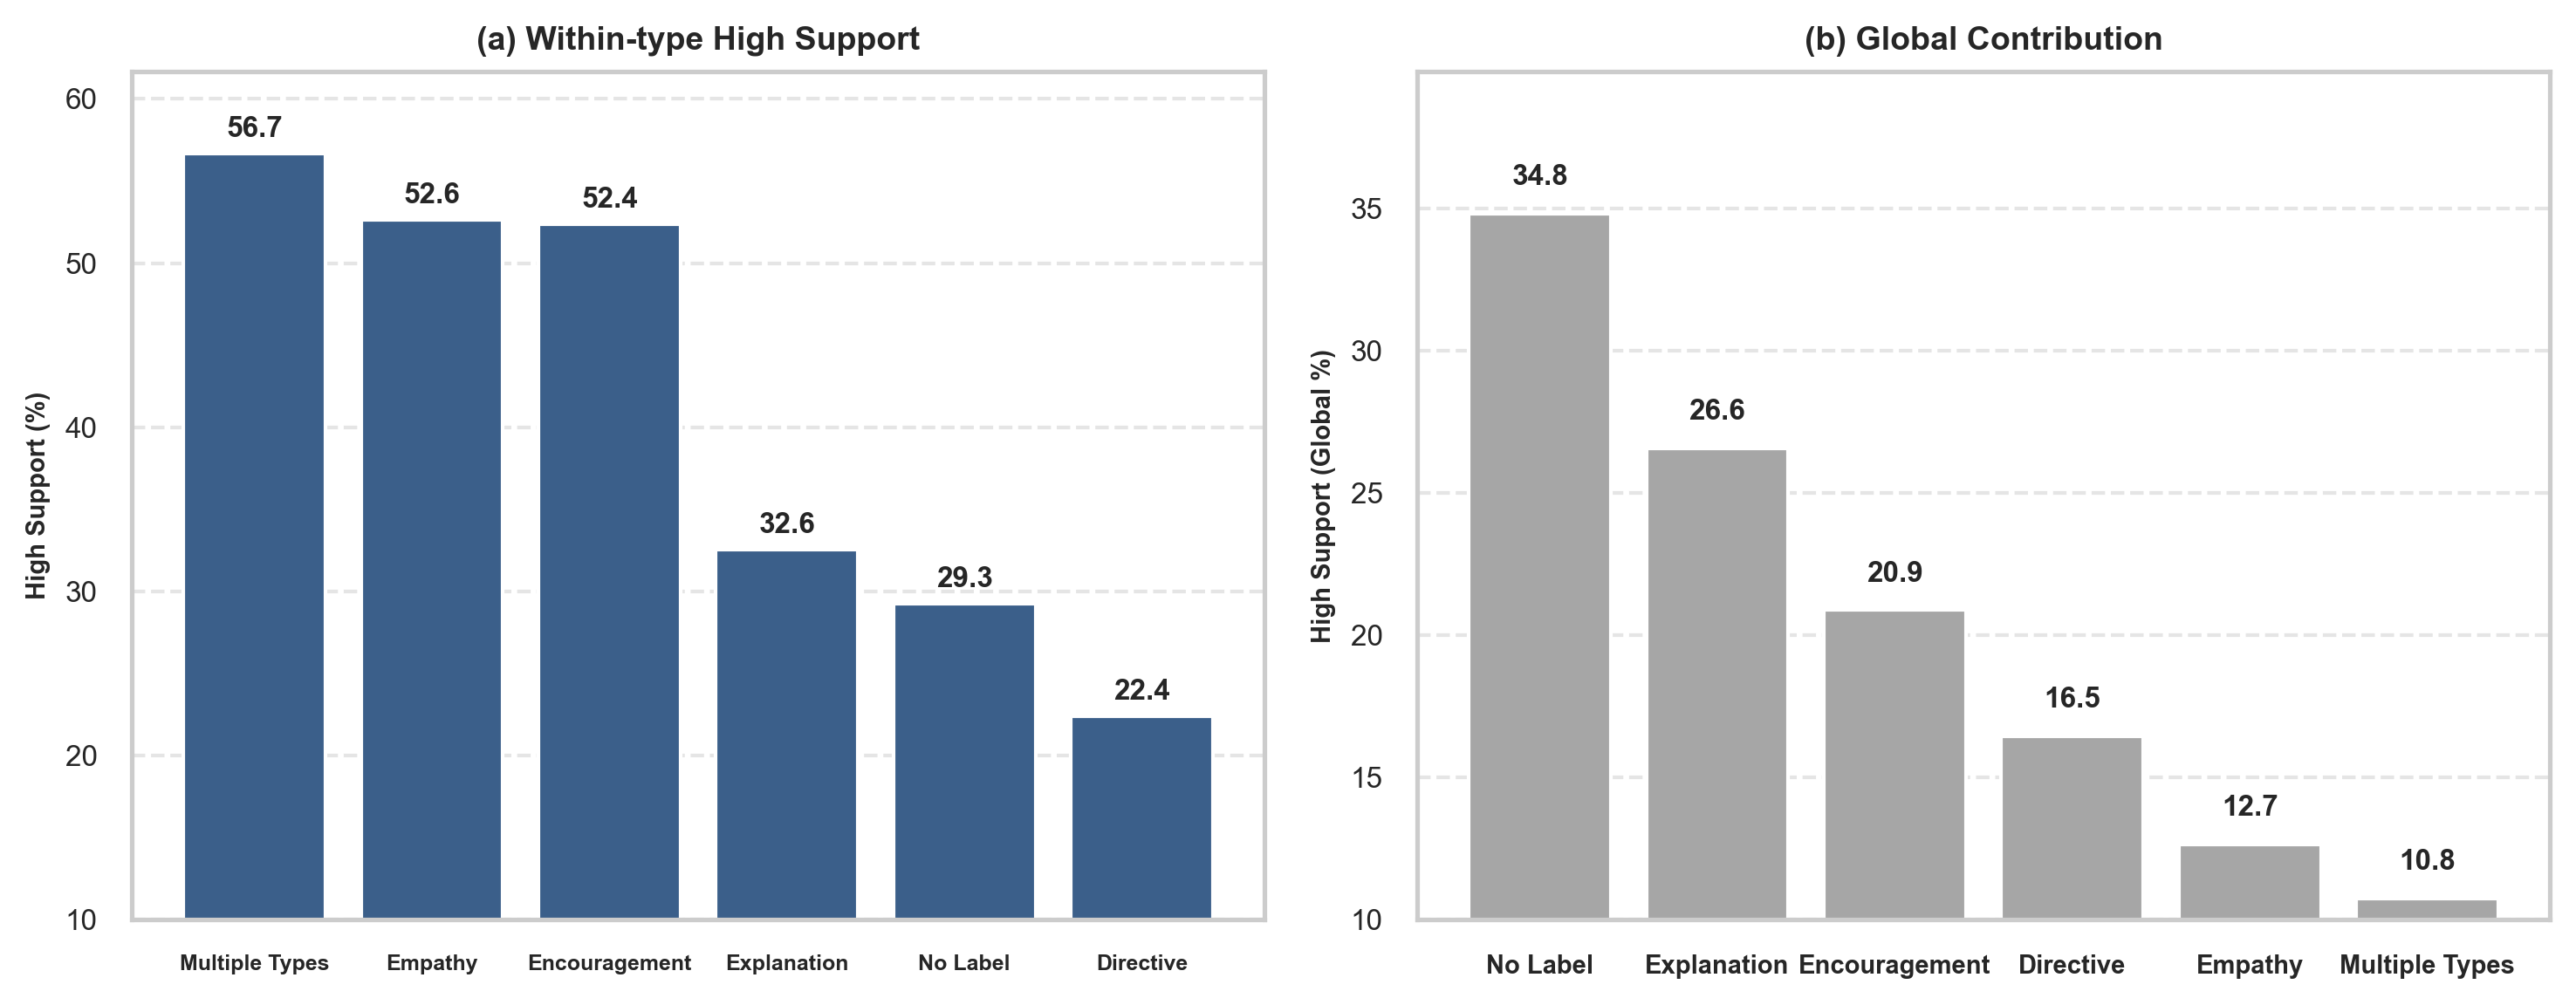

In [108]:
# Combined figure (Fig 2a + 2b)

fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=300)

# -------- (a) High Support (%) --------
df1 = result_df.sort_values("High Support (%)", ascending=False)

axes[0].bar(
    df1["Condition"],
    df1["High Support (%)"],
    color="#3B5F8A"
)

for i, v in enumerate(df1["High Support (%)"]):
    axes[0].text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

axes[0].set_ylabel("High Support (%)", fontsize=7, weight="bold")
axes[0].set_title("(a) Within-type High Support", fontsize=9,fontweight="bold")
axes[0].set_xticklabels(df1["Condition"], rotation=0, fontsize=6, fontweight="bold")
axes[0].set_ylim(10, max(df1["High Support (%)"]) + 5)
axes[0].tick_params(axis='y', labelsize=8)

axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].grid(axis='x', visible=False)


# -------- (b) High Support (Global %) --------
df2 = result_df.sort_values("High Support (Global %)", ascending=False)

axes[1].bar(
    df2["Condition"],
    df2["High Support (Global %)"],
    color="#A6A6A6"
)

for i, v in enumerate(df2["High Support (Global %)"]):
    axes[1].text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

axes[1].set_ylabel("High Support (Global %)", fontsize=7, weight="bold")
axes[1].set_title("(b) Global Contribution", fontsize=9,fontweight="bold")
axes[1].set_xticklabels(df2["Condition"], rotation=0, fontsize=7, fontweight="bold")
axes[1].set_ylim(10, max(df2["High Support (Global %)"]) + 5)
axes[1].tick_params(axis='y', labelsize=8)

axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].grid(axis='x', visible=False)


plt.tight_layout()
plt.savefig("figure2_combined.pdf", bbox_inches='tight')
plt.show()

In [136]:
# Check the original data of no labeled highscore
no_labeled_highscore = type_response[
    (type_response["TR_total"] == 0) &
    (type_response["support_avg"] >= 4)
]

no_labeled_highscore = no_labeled_highscore.merge(
    df[["id", "context"]],
    on="id",
    how="left"
)

no_labeled_highscore[["context", "teacher_response", "support_avg"]].columns

Index(['context', 'teacher_response', 'support_avg'], dtype='object')

`Summary`

Some high-support responses in the No Labeled category are not task-related but show interest in students’ personal or off-topic contributions. Although such responses were not annotated under the current scheme, they may still be perceived as supportive, as interactions tailored to students’ individual interests can resonate with them and foster a sense of support. This indicates that certain forms of support are not captured by the existing categories.

In [110]:
# Filter multiple-type responses with high support (support_avg >= 4)
multi_high = multi[multi["support_avg"] >= 4].copy()

# Compute distribution of strategy combinations
combo_high = multi_high["combination"].value_counts().reset_index()
combo_high.columns = ["Combination", "Count"]

# Calculate percentage within the multiple high-support subset
combo_high["Percentage (%)"] = (
    combo_high["Count"] / combo_high["Count"].sum() * 100
).round(1)

# Set combination as index for display
combo_high.set_index("Combination")

,Count,Percentage (%)
Combination,,
"(TR_Encouragement, TR_Explanation)",6,35.3
"(TR_Encouragement, TR_Directive)",4,23.5
"(TR_Empathy, TR_Explanation)",3,17.6
"(TR_Empathy, TR_Encouragement)",2,11.8
"(TR_Empathy, TR_Explanation, TR_Directive)",1,5.9
"(TR_Empathy, TR_Directive)",1,5.9


`Summary`

Some combinations involving affective strategies (e.g., encouragement + explanation) appear to show higher support rates than those dominated by directive elements, although this observation is limited by small sample sizes.

`Summary for Hight-Support Patterns`

Overall, perceived emotional support is influenced by both individual response types and their combinations: affective response types and their combinations tend to be more effective in eliciting support, while non-labeled responses contribute substantially due to their frequency, indicating both usage patterns and limitations in the current annotation scheme.

## 3.2 Statistical Testing (t-tests)

**Empathy**

In [111]:
from scipy.stats import ttest_ind

# Mean support scores (from aggregated table)
mean_not_used = TR_Em_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Em_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Empathy"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Empathy"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Empathy):", round(mean_used, 2))
print("Mean (Not Using Empathy):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Empathy): 3.64
Mean (Not Using Empathy): 3.12
t = 3.460, p = 0.0012


`Summary`

The average support score is higher when Empathy is used (M = 3.64) compared to when it is not used (M = 3.12), and this difference is statistically significant (t = 3.46, p = 0.0012).

**Encouragement**

In [112]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Ec_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Ec_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Encouragement"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Encouragement"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Encouragement):", round(mean_used, 2))
print("Mean (Not Using Encouragement):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Encouragement): 3.73
Mean (Not Using Encouragement): 3.08
t = 5.940, p = 0.0000


`Summary`

The average support score is higher when Encouragement is used (M = 3.73) compared to when it is not used (M = 3.08), and this difference is highly statistically significant (t = 5.94, p < 0.001).

**Explanation**

In [113]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Ex_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Ex_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Explanation"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Explanation"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Explanation):", round(mean_used, 2))
print("Mean (Not Using Explanation):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Explanation): 3.26
Mean (Not Using Explanation): 3.13
t = 1.318, p = 0.1886


`Summary` 

The difference between responses with and without <b>Explanation</b> is not statistically significant (p = 0.19), suggesting that explanation alone does not strongly influence perceived support.

**Directive**

In [114]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Dr_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Dr_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Directive"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Directive"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Directive):", round(mean_used, 2))
print("Mean (Not Using Directive):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Directive): 2.8
Mean (Not Using Directive): 3.27
t = -4.292, p = 0.0000


`Summary`

The average support score is lower when <b>Directive</b> is used (M = 2.80) compared to when it is not used (M = 3.27), and this difference is statistically significant (t = -4.29, p < 0.001).

`Summary for the whole t-tests`

Affective response types such as Encouragement and Empathy are significantly associated with higher perceived support, while Directive responses show a significant negative association. In contrast, Explanation does not exhibit a significant effect, suggesting that informational content alone may not be sufficient to enhance perceived support.

## 3.3 Regression Analysis

In [115]:
import statsmodels.api as sm

X = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]]

y = type_response["support_avg"]

# Add intercept term
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            support_avg   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     14.21
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           5.43e-11
Time:                        16:37:00   Log-Likelihood:                -678.74
No. Observations:                 503   AIC:                             1367.
Df Residuals:                     498   BIC:                             1389.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.1037      0.065  

`Summary` 

A linear regression analysis was conducted to examine the independent effects of response types on perceived support. The results show that Encouragement (β = 0.66, p < 0.001) and Empathy (β = 0.51, p = 0.002) are significantly associated with higher support scores, while Directive responses are associated with lower support (β = −0.38, p < 0.001). In contrast, Explanation does not show a significant effect (p = 0.35). These findings are consistent with the descriptive and t-test results, indicating that affective response types have a stronger positive association with perceived support than instructional or directive ones.

## 4 Linguistic Patterns in High-Support Responses

### 4.1 Length and Structural Features

In [116]:
type_response["length"] = type_response["teacher_response"].str.split().apply(len)

type_response["high_support"] = (type_response["support_avg"] >= 4).astype(int)

In [117]:
length_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Avg_Length=("length", "mean"))
)

length_summary["Support Level"] = length_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

length_summary = (
    length_summary
    .drop(columns="high_support")
    .round(2)
)
length_summary.set_index("Support Level")

,Avg_Length
Support Level,
Low Support,12.53
High Support,14.68


In [118]:
from scipy.stats import ttest_ind

high = type_response[type_response["high_support"] == 1]["length"]
low = type_response[type_response["high_support"] == 0]["length"]

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Avg Length: {high.mean():.2f}")
print(f"Low Support Avg Length: {low.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Avg Length: 14.68
Low Support Avg Length: 12.53
t = 2.627, p = 0.0091


`Summary`

High-support responses are longer on average (M = 14.68) than low-support responses (M = 12.53), and this difference is statistically significant (t = 2.63, p = 0.009), suggesting that more elaborated responses may contribute to higher perceived support.

### 4.2 Affective and Politeness Markers

**affective marks** 

In [119]:
affective_words = [
    "good", "great", "nice", "well done", "interesting",
    "i understand", "i see", "don't worry", "no worries",
    "you’re right", "that's right", "exactly"
]

In [120]:
type_response["response_lower"] = type_response["teacher_response"].str.lower()

In [121]:
type_response["has_affective"] = type_response["response_lower"].apply(
    lambda x: any(word in x for word in affective_words)
).astype(int)

In [122]:
aff_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Affective_Rate=("has_affective", "mean"))
)

aff_summary["Support Level"] = aff_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

aff_summary["Affective_Rate"] = (aff_summary["Affective_Rate"] * 100).round(2)

aff_summary = aff_summary.drop(columns="high_support")
aff_summary.set_index("Support Level")

,Affective_Rate
Support Level,
Low Support,22.03
High Support,35.44


In [123]:
high = type_response[type_response["high_support"] == 1]["has_affective"]
low = type_response[type_response["high_support"] == 0]["has_affective"]

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Affective Rate: {high.mean()*100:.2f}%")
print(f"Low Support Affective Rate: {low.mean()*100:.2f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Affective Rate: 35.44%
Low Support Affective Rate: 22.03%
t = 3.032, p = 0.0027


`Summary`

High-support responses contain affective language more frequently (35.44%) than low-support responses (22.03%), and this difference is statistically significant (t = 3.03, p = 0.003), indicating that emotionally supportive expressions are associated with higher perceived support.

**Politeness Markers**

In [124]:
politeness_words = [
    "please", "thank you", "thanks",
    "could you", "can you", "would you",
    "let's", "shall we",
    "you might", "you could",
    "feel free", "i suggest", "i recommend"
]

In [125]:
type_response["has_politeness"] = type_response["response_lower"].apply(
    lambda x: any(word in x for word in politeness_words)
).astype(int)

In [126]:
pol_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Politeness_Rate=("has_politeness", "mean"))
)

pol_summary["Support Level"] = pol_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

pol_summary["Politeness_Rate"] = (pol_summary["Politeness_Rate"] * 100).round(2)

pol_summary = pol_summary.drop(columns="high_support")
pol_summary.set_index("Support Level")

,Politeness_Rate
Support Level,
Low Support,10.14
High Support,14.56


In [127]:
from scipy.stats import ttest_ind

high = type_response[type_response["high_support"] == 1]["has_politeness"]
low = type_response[type_response["high_support"] == 0]["has_politeness"]

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Politeness Rate: {high.mean()*100:.2f}%")
print(f"Low Support Politeness Rate: {low.mean()*100:.2f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Politeness Rate: 14.56%
Low Support Politeness Rate: 10.14%
t = 1.357, p = 0.1760


`Summary` 

Politeness-related expressions appear slightly more frequently in high-support responses (14.56%) than in low-support responses (10.14%), but the difference is not statistically significant (p = 0.18), suggesting that politeness alone may not play a decisive role in perceived support.